In this project，I want to use the dataset of lbs,to calculate the age at death (YoD - YoB) and analyze the age distribution of the individuals in the dataset.

First, I should set up.

In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv("D:\intro-to-ds-project-XuyangZhang\project1\lbs.tsv",delimiter="\t")

Then, I want to check the columns and types of our dataset.

In [3]:
df.columns

Index(['PersonID', 'FirstName', 'FamilyName', 'Title', 'Sex', 'YoB', 'YoD',
       'BuildingType', 'BuildingName', 'BuildingDescr', 'Location', 'County',
       'Cost', 'BuiltDate', 'InternetLink', 'Ownership'],
      dtype='object')

In [4]:
df.dtypes

PersonID           int64
FirstName         object
FamilyName        object
Title             object
Sex               object
YoB              float64
YoD              float64
BuildingType      object
BuildingName      object
BuildingDescr     object
Location          object
County            object
Cost              object
BuiltDate        float64
InternetLink      object
Ownership         object
dtype: object

Next, I want to describe our dataset.

In [5]:
df.describe(include = "all")

,PersonID,FirstName,FamilyName,Title,Sex,YoB,YoD,BuildingType,BuildingName,BuildingDescr,Location,County,Cost,BuiltDate,InternetLink,Ownership
count,6.260000e+02,626,626,97,625,280.000000,278.000000,619,618,523,538,562,27,202.000000,382,160
unique,NaN,238,396,22,2,NaN,NaN,31,583,522,469,72,23,NaN,365,25
top,NaN,John,Hibbert,Sir,M,NaN,NaN,Country house,Poltalloch House,"Built by John Anthony Rucker, who left it toge...",Glasgow,Surrey,�2000,NaN,http://www.british-history.ac.uk/vch/hants/vol...,Private owners
freq,NaN,86,12,52,593,NaN,NaN,341,3,2,5,48,3,NaN,3,65
mean,1.264916e+09,NaN,NaN,NaN,NaN,1760.550000,1832.737410,NaN,NaN,NaN,NaN,NaN,NaN,1812.787129,NaN,NaN
std,1.070907e+09,NaN,NaN,NaN,NaN,31.420566,35.042101,NaN,NaN,NaN,NaN,NaN,NaN,42.887789,NaN,NaN
min,-2.081598e+09,NaN,NaN,NaN,NaN,1631.000000,1701.000000,NaN,NaN,NaN,NaN,NaN,NaN,1661.000000,NaN,NaN
25%,2.495200e+04,NaN,NaN,NaN,NaN,1741.500000,1809.250000,NaN,NaN,NaN,NaN,NaN,NaN,1792.000000,NaN,NaN
50%,2.146635e+09,NaN,NaN,NaN,NaN,1760.000000,1836.000000,NaN,NaN,NaN,NaN,NaN,NaN,1814.000000,NaN,NaN
75%,2.146645e+09,NaN,NaN,NaN,NaN,1787.000000,1859.000000,NaN,NaN,NaN,NaN,NaN,NaN,1837.750000,NaN,NaN


Next, I want to divide without NaN by total length revealing which columns have missing values.This will help us known whether the dataset having some NaNs.If it has,I should clean our dataset by dealing with these missing datas.

In [ ]:
df.count() / len(df)

PersonID         1.000000
FirstName        1.000000
FamilyName       1.000000
Title            0.154952
Sex              0.998403
YoB              0.447284
YoD              0.444089
BuildingType     0.988818
BuildingName     0.987220
BuildingDescr    0.835463
Location         0.859425
County           0.897764
Cost             0.043131
BuiltDate        0.322684
InternetLink     0.610224
Ownership        0.255591
dtype: float64

After we dividing without NaN by total length,the length of PersonID and FirstName and FamilyName is 1 which means in these 3 columns there's no NaN.But in other column which length is not 1,meaning there are some NaN.Then we should deal with this situation.

Before we delete NaN, I want to take a look at all of the items that do have YoB.

In [ ]:
df[df["YoB"].notna()]["YoB"]

0      1631.0
1      1652.0
2      1669.0
3      1673.0
4      1678.0
        ...  
275    1809.0
276    1812.0
277    1812.0
278    1815.0
279    1826.0
Name: YoB, Length: 280, dtype: float64

Taking a look at all of the items that do have YoD

In [ ]:
df[df["YoD"].notna()]["YoD"]

0      1701.0
1      1733.0
2      1741.0
3      1743.0
4      1748.0
        ...  
275    1905.0
276    1888.0
277    1888.0
278    1894.0
279    1904.0
Name: YoD, Length: 278, dtype: float64

Taking a look at all of the items that do not have YoB or YoD.

In [ ]:
print("missing count：")
print(df[['YoB', 'YoD']].isnull().sum())

missing count：
YoB    346
YoD    348
dtype: int64


Deleting missing data and show the data.

In [ ]:
df_clean = df.dropna(subset=['YoB', 'YoD']).copy()
display(df_clean.head())

,PersonID,FirstName,FamilyName,Title,Sex,YoB,YoD,BuildingType,BuildingName,BuildingDescr,Location,County,Cost,BuiltDate,InternetLink,Ownership
0,2146644597,Ralph,Fretwell,NaN,M,1631.0,1701.0,Country house,Hellaby Hall,"Late 17thC mansion house near Rotherham, built...",near Rotherham,Yorkshire,NaN,NaN,https://historicengland.org.uk/listing/the-lis...,Private - hotel
1,2146652093,Gilbert,Heathcote,Sir,M,1652.0,1733.0,Country house,Normanton Hall,"Built by Sir Gilbert Heathcote, who had purcha...",NaN,Rutland,�20000,NaN,NaN,NaN
2,2146645491,James,Milliken,NaN,M,1669.0,1741.0,Country house,Milliken House,Built by James Milliken after his return from ...,Milliken,Renfrewshire,NaN,1733.0,http://rlhf.info/the-tower-at-milliken-a-hidde...,NaN
3,2146650419,Alexander,Porterfield,NaN,M,1673.0,1743.0,Country house,Duchal House,NaN,Kilmacolm,Renfrewshire,NaN,1710.0,NaN,NaN
4,2146646095,William,McDowall,Col.,M,1678.0,1748.0,Country house,Castle Semple House,Col. William McDowall bought the Castle Semple...,Lochwinnoch,Renfrewshire,NaN,1727.0,http://portal.historic-scotland.gov.uk/designa...,NaN


I want to calculate the age at death,so I should ensure the YoD >= YoB,Which is important.
Then checking if YoD >= YoB and show the data.

In [ ]:
invalid_mask = df_clean['YoD'] < df_clean['YoB']
if invalid_mask.any():
    print(f"found {invalid_mask.sum()} useless data（YoD < YoB），deleted.")
    df_clean = df_clean[~invalid_mask].copy()
display(df_clean.head())

,PersonID,FirstName,FamilyName,Title,Sex,YoB,YoD,BuildingType,BuildingName,BuildingDescr,Location,County,Cost,BuiltDate,InternetLink,Ownership
0,2146644597,Ralph,Fretwell,NaN,M,1631.0,1701.0,Country house,Hellaby Hall,"Late 17thC mansion house near Rotherham, built...",near Rotherham,Yorkshire,NaN,NaN,https://historicengland.org.uk/listing/the-lis...,Private - hotel
1,2146652093,Gilbert,Heathcote,Sir,M,1652.0,1733.0,Country house,Normanton Hall,"Built by Sir Gilbert Heathcote, who had purcha...",NaN,Rutland,�20000,NaN,NaN,NaN
2,2146645491,James,Milliken,NaN,M,1669.0,1741.0,Country house,Milliken House,Built by James Milliken after his return from ...,Milliken,Renfrewshire,NaN,1733.0,http://rlhf.info/the-tower-at-milliken-a-hidde...,NaN
3,2146650419,Alexander,Porterfield,NaN,M,1673.0,1743.0,Country house,Duchal House,NaN,Kilmacolm,Renfrewshire,NaN,1710.0,NaN,NaN
4,2146646095,William,McDowall,Col.,M,1678.0,1748.0,Country house,Castle Semple House,Col. William McDowall bought the Castle Semple...,Lochwinnoch,Renfrewshire,NaN,1727.0,http://portal.historic-scotland.gov.uk/designa...,NaN


Finally,I can calculate the age and show the data.Before this part,I have done lots of important things.Although the before parts could not calculate the result I want derectly.Ther are important.Without the before parts I will not get the answer I want.

In [ ]:
df_clean['Age'] = df_clean['YoD'] - df_clean['YoB']
display(df_clean.head())

,PersonID,FirstName,FamilyName,Title,Sex,YoB,YoD,BuildingType,BuildingName,BuildingDescr,Location,County,Cost,BuiltDate,InternetLink,Ownership,Age
0,2146644597,Ralph,Fretwell,NaN,M,1631.0,1701.0,Country house,Hellaby Hall,"Late 17thC mansion house near Rotherham, built...",near Rotherham,Yorkshire,NaN,NaN,https://historicengland.org.uk/listing/the-lis...,Private - hotel,70.0
1,2146652093,Gilbert,Heathcote,Sir,M,1652.0,1733.0,Country house,Normanton Hall,"Built by Sir Gilbert Heathcote, who had purcha...",NaN,Rutland,�20000,NaN,NaN,NaN,81.0
2,2146645491,James,Milliken,NaN,M,1669.0,1741.0,Country house,Milliken House,Built by James Milliken after his return from ...,Milliken,Renfrewshire,NaN,1733.0,http://rlhf.info/the-tower-at-milliken-a-hidde...,NaN,72.0
3,2146650419,Alexander,Porterfield,NaN,M,1673.0,1743.0,Country house,Duchal House,NaN,Kilmacolm,Renfrewshire,NaN,1710.0,NaN,NaN,70.0
4,2146646095,William,McDowall,Col.,M,1678.0,1748.0,Country house,Castle Semple House,Col. William McDowall bought the Castle Semple...,Lochwinnoch,Renfrewshire,NaN,1727.0,http://portal.historic-scotland.gov.uk/designa...,NaN,70.0


Decriptive statistics of Age

In [ ]:
age_stats = df_clean['Age'].describe(percentiles=[0.25, 0.5, 0.75, 0.95])
print("Decriptive statistics of Age：")
display(age_stats)

Decriptive statistics of Age：


count    278.000000
mean      72.514388
std       12.677540
min       28.000000
25%       64.000000
50%       75.500000
75%       82.000000
95%       90.150000
max       98.000000
Name: Age, dtype: float64

In the above figure, descriptive statistics for age are presented. It can be seen that there are 278 valid data points in total. The minimum age is as low as 28, while the maximum age is 98. The mean age is around 72.5, with a standard deviation of approximately 12.7. This indicates a substantial difference between the oldest and youngest ages, yet the age variation remains within a 13-year range.

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

density map and histogra

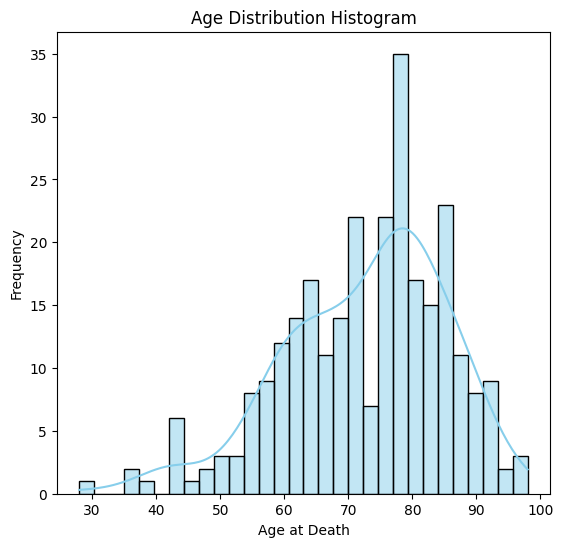

In [ ]:
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
sns.histplot(df_clean['Age'], bins=30, kde=True, color='skyblue')
plt.title('Age Distribution Histogram')
plt.xlabel('Age at Death')
plt.ylabel('Frequency')
plt.show()

box plot

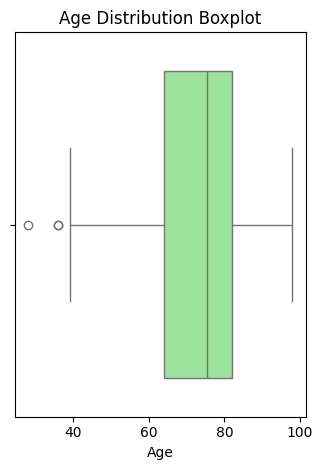

In [ ]:
plt.subplot(1, 2, 2)
sns.boxplot(x=df_clean['Age'], color='lightgreen')
plt.title('Age Distribution Boxplot')
plt.xlabel('Age')
plt.tight_layout()
plt.show()

The above two figures are a density map and a histogram, and a box plot. They visually show that most people's ages fall between 60 and 80, which is consistent with the previous descriptive statistics.

Deep analyse

Generate a birth year column (in groups of 10 years)，Calculate the average age at death for each decade

In [ ]:
df_clean['BirthDecade'] = (df_clean['YoB'] // 10) * 10

decade_stats = df_clean.groupby('BirthDecade')['Age'].agg(['mean', 'median', 'count'])
print("Statistics grouped by birth decade：")
display(decade_stats)


Statistics grouped by birth decade：


,mean,median,count
BirthDecade,,,
1630.0,70.000000,70.0,1
1650.0,81.000000,81.0,1
1660.0,72.000000,72.0,1
1670.0,67.750000,70.0,4
1690.0,60.000000,55.0,3
1700.0,61.000000,61.0,1
1710.0,74.000000,76.0,14
1720.0,67.947368,69.0,19
1730.0,69.350000,64.5,20


Plot a trend graph

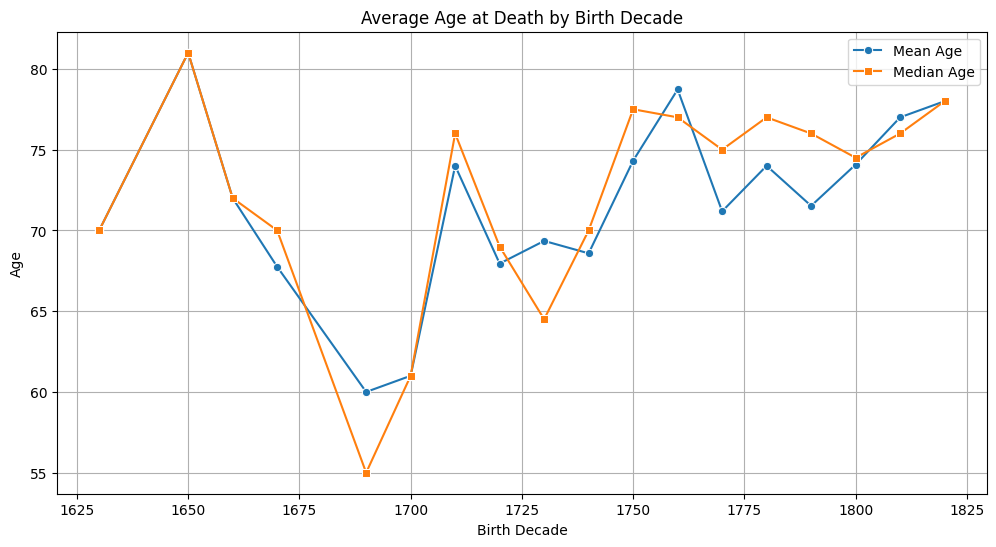

In [ ]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=decade_stats, x=decade_stats.index, y='mean', marker='o', label='Mean Age')
sns.lineplot(data=decade_stats, x=decade_stats.index, y='median', marker='s', label='Median Age')
plt.title('Average Age at Death by Birth Decade')
plt.xlabel('Birth Decade')
plt.ylabel('Age')
plt.legend()
plt.grid(True)
plt.show()

The last graph is an in - depth analysis. I categorized samples every ten years, calculating the mean and median age for each. Plotting the data on a timeline against age, I observed a significant drop in the periods 1675 - 1700 and after 1725.

Conclusion

By learning some simple Python tools, I can quickly process large - scale data that needs cleaning and perform basic data analysis.
Finally, I can visualize the data and make meaningful analyses.
After installing the necessary commands, I imported the data and processed it, such as viewing and removing missing values.
In this project, I want to calculate people's lifespans, visualize the results in different charts, and conduct simple analyses.
The first class showed me that data handling isn't too hard, even though I made mistakes initially. 
I felt thrilled when I solved problems and created meaningful graphs using Python. 
I'm delighted that my major connects with real - life issues. 

In this project, I utilised chatgpt to assist with various aspects of process, for example I used it to help generate code and debug bugs